In [ ]:
import pandas as pd
import numpy as np
df = pd.DataFrame({
    'Age': [25, 30, np.nan, 40, 35],
    'Department': ['HR', 'Finance', 'Finance', np.nan, 'IT']
})
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Department'] = df['Department'].fillna(df['Department'].mode()[0])
print(df)

    Age Department
0  25.0         HR
1  30.0    Finance
2  32.5    Finance
3  40.0    Finance
4  35.0         IT


In [ ]:
import pandas as pd
import numpy as np
df = pd.DataFrame({
    'Age': [25, 30, np.nan, 40, 35],
    'Department': ['HR', 'Finance', 'Finance', np.nan, 'IT']
})
df_ffill = df.copy()
df_ffill = df_ffill.ffill()
print(df_ffill)

    Age Department
0  25.0         HR
1  30.0    Finance
2  30.0    Finance
3  40.0    Finance
4  35.0         IT


In [ ]:
import pandas as pd
import numpy as np
df = pd.DataFrame({
    'Age': [25, 30, np.nan, 40, 35],
    'Department': ['HR', 'Finance', 'Finance', np.nan, 'IT']
})
df_bfill = df.copy()
df_bfill = df_bfill.bfill()
print(df_bfill)

    Age Department
0  25.0         HR
1  30.0    Finance
2  40.0    Finance
3  40.0         IT
4  35.0         IT


In [ ]:
import pandas as pd
import numpy as np
df = pd.DataFrame({
    'Age': [25, 30, np.nan, 40, 35],
    'Department': ['HR', 'Finance', 'Finance', np.nan, 'IT']
})
df_drop_rows = df.dropna()
print("After dropping rows:\n", df_drop_rows)
df_drop_cols = df.dropna(axis=1)
print("\nAfter dropping columns:\n", df_drop_cols)

After dropping rows:
     Age Department
0  25.0         HR
1  30.0    Finance
4  35.0         IT

After dropping columns:
 Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4]


In [ ]:
import pandas as pd
df = pd.DataFrame({
    'ID':   [1, 2, 2, 3, 4, 4],
    'Name': ['Alice', 'Bob', 'Bob', 'Charlie', 'David', 'David'],
    'Age':  [25, 30, 30, 35, 40, 40]
})
print("Original Data:\n", df)
df_exact = df.drop_duplicates()
print("\nAfter Exact Match Removal:\n", df_exact)

Original Data:
    ID     Name  Age
0   1    Alice   25
1   2      Bob   30
2   2      Bob   30
3   3  Charlie   35
4   4    David   40
5   4    David   40

After Exact Match Removal:
    ID     Name  Age
0   1    Alice   25
1   2      Bob   30
3   3  Charlie   35
4   4    David   40


In [ ]:
df_subset_id = df.drop_duplicates(subset=['ID'])
print("After Subset-Based Removal (ID):\n", df_subset_id)
df_subset_name = df.drop_duplicates(subset=['Name'])
print("\nAfter Subset-Based Removal (Name):\n", df_subset_name)

After Subset-Based Removal (ID):
    ID     Name  Age
0   1    Alice   25
1   2      Bob   30
3   3  Charlie   35
4   4    David   40

After Subset-Based Removal (Name):
    ID     Name  Age
0   1    Alice   25
1   2      Bob   30
3   3  Charlie   35
4   4    David   40


In [ ]:
import pandas as pd
df = pd.DataFrame({
    'Date': ['2025-01-05', '05/01/2025', 'Jan 5, 2025', '2025.01.05']
})
df['Date'] = pd.to_datetime(df['Date'], errors='coerce').dt.strftime('%Y-%m-%d')
print(df)

         Date
0  2025-01-05
1         NaN
2         NaN
3         NaN


In [ ]:
df = pd.DataFrame({
    'Name': ['Alice', 'BOB', 'charlie', 'DAVID']
})
df['Name_lower'] = df['Name'].str.lower()
df['Name_upper'] = df['Name'].str.upper()
print(df)

      Name Name_lower Name_upper
0    Alice      alice      ALICE
1      BOB        bob        BOB
2  charlie    charlie    CHARLIE
3    DAVID      david      DAVID


In [ ]:
import pandas as pd
import numpy as np
data = pd.Series([10, 12, 12, 13, 12, 11, 14, 13, 200, 12, 11, 13])
mean, std = data.mean(), data.std()
z_scores = (data - mean) / std
outliers_z = data[np.abs(z_scores) > 3]
print("Z-score outliers:\n", outliers_z.tolist())
Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers_iqr = data[(data < lower) | (data > upper)]
print("IQR outliers:", outliers_iqr.tolist())
print("IQR bounds:", round(lower, 2), "to", round(upper, 2))

Z-score outliers:
 [200]
IQR outliers: [200]
IQR bounds: 9.88 to 14.88


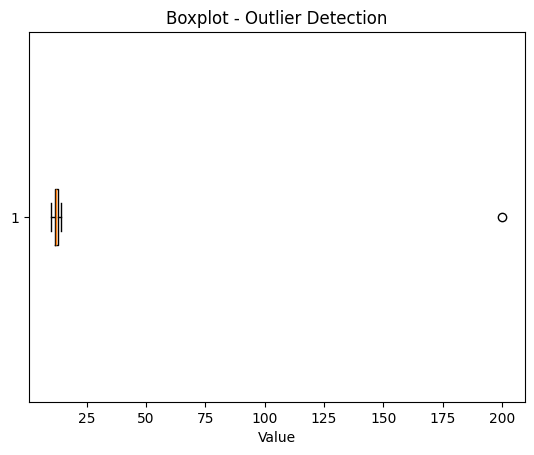

In [ ]:
import matplotlib.pyplot as plt
plt.boxplot(data, vert=False)
plt.title("Boxplot - Outlier Detection")
plt.xlabel("Value")
plt.show()